## 02的可视化

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import glob
import re
import numpy as np

def plot_scaling_results(experiment_path, scale_name):
    """
    experiment_path: 实验时间根目录，如 'output/20260326_163751'
    scale_name: 需要画图的参数量档位，如 '30M'
    """
    target_dir = os.path.join(experiment_path, scale_name)
    if not os.path.exists(target_dir):
        print(f"错误: 找不到目录 {target_dir}")
        return

    # 1. 获取该目录下所有的 L{x}.csv 文件
    csv_files = glob.glob(os.path.join(target_dir, "L*.csv"))
    
    # 对文件名进行排序，确保 L2, L3 ... L25 按顺序排列
    def sort_key(s):
        nums = re.findall(r'\d+', os.path.basename(s))
        return int(nums[0]) if nums else 0
    
    csv_files.sort(key=sort_key)

    if not csv_files:
        print(f"在 {target_dir} 中没有找到任何评估 CSV 文件。")
        return

    # 2. 开始绘图
    plt.figure(figsize=(12, 7), dpi=150)
    
    # 使用颜色映射，让难度 L 的颜色产生渐变
    cmap = plt.get_cmap('viridis')
    colors = [cmap(i) for i in np.linspace(0, 0.8, len(csv_files))]

    for i, file_path in enumerate(csv_files):
        shard_name = os.path.basename(file_path).replace(".csv", "")
        df = pd.read_csv(file_path)
        
        # 确保数据按信息熵排序（防止乱序写入）
        df = df.sort_values("cumulative_entropy")

        plt.plot(
            df["cumulative_entropy"], 
            df["eval_loss"], 
            label=f"Difficulty {shard_name}",
            color=colors[i],
            linewidth=1.5,
            alpha=0.8
        )

    # 3. 装饰图表
    plt.title(f"Logic Reasoning Scaling Law - Model Scale: {scale_name}", fontsize=14)
    plt.xlabel("Cumulative Training Entropy (bits)", fontsize=12)
    plt.ylabel("Evaluation Loss", fontsize=12)
    
    # 网格线
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # 侧边栏图例（因为 L 很多，放在外面比较好）
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small', ncol=2)
    
    plt.tight_layout()

    # # 4. 保存与展示
    # save_path = os.path.join(target_dir, f"scaling_curve_{scale_name}.png")
    # plt.savefig(save_path)
    # print(f"图表已保存至: {save_path}")
    plt.show()

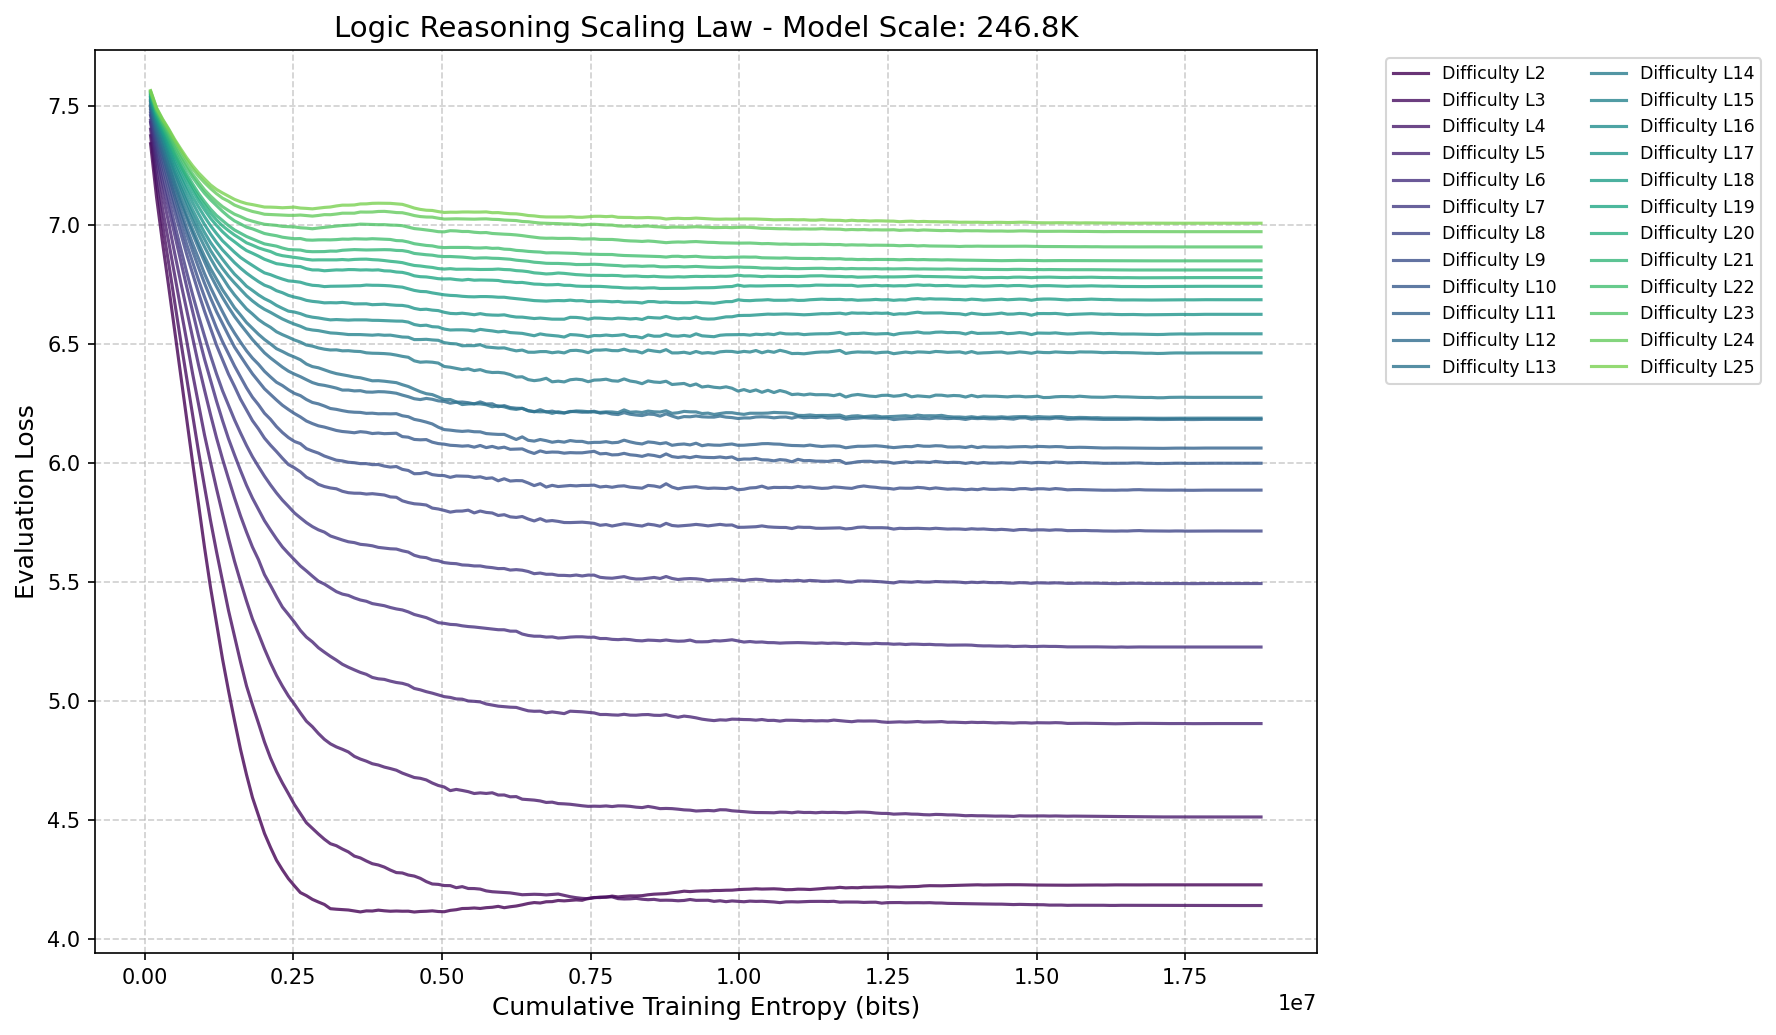

In [3]:
plot_scaling_results("output/20260326_160608", "246.8K")